In [ ]:
from run_inference import *

def load_models(name="best", expt_id=None, device="cpu"):
    if expt_id is None:
        expt_id = experiment_id

    if name not in ["best", "last", "latest"]:
        raise NotImplementedError("Only `best`, `last`, and `latest` models are supported")
    
    if name=="best":
        suffix = ""
    else:
        suffix = f"_{name}"
    
    print(f"Loading `{name}` model")

    model = torch.load(f"models/{expt_id}/model{suffix}.pt", map_location=device, weights_only=False)
    scoremodel = torch.load(f"models/{expt_id}/scmodel{suffix}.pt", map_location=device, weights_only=False)
    embed_model = torch.load(f"models/{expt_id}/embed_model{suffix}.pt", map_location=device, weights_only=False)
    if os.path.exists(f"models/{expt_id}/preembed_model{suffix}.pt"):
        preembed_model = torch.load(f"models/{expt_id}/preembed_model{suffix}.pt", map_location=device, weights_only=False)
    else:
        tokenize_transform = lambda x: tokenize(x, args)[0]
        preembed_model = TransformInput(tokenize_transform).to(device)
    
    if os.path.exists(f"models/{expt_id}/aggregator{suffix}.pt"):
        aggregator = torch.load(f"models/{expt_id}/aggregator{suffix}.pt", map_location=device, weights_only=False)
    else:
        aggregator = None

    return model, scoremodel, embed_model, preembed_model, aggregator

@torch.no_grad()
def compute_scores(dataset, model, scoremodel, embed_model, preembed_model, image_embed_model=None, stagger=2, verbose=False, aggregator=None):
    loader = dataset.get_dataloader(batch_size=100, shuffle=True)

    C = embed_full_corpus(dataset, embed_model, preembed_model, image_embed_model=image_embed_model, aggregator=aggregator)
    # C is (N, n, xoutdim)

    normscores = []
    lamscores = []
    netscores = []
    true_labels = []
    for n, (q, l) in enumerate(tqdm(loader, leave=False, disable=not verbose)):
        q = q.to(next(model.parameters()).device) 
        # q is bmd, c is Nnd, l is bN
        q = q + batch_get_white_noise(q, args.SNR)     # torch.randn_like(q) * noise
        q = embed_if_image_and_normalize(q, image_embed_model)
        q = embed_model(preembed_model(q))
        q = normalize(q)
        # q is (b, m, xoutdim)
        if aggregator is None:
            qct = torch.einsum("bmd,Nnd->bNmn", q, C)
            if isinstance(model, LamModel):
                model_inputs = stagger_and_concat(qct, num_stagger=stagger) # bNsmn  s = num_stagger+1

                lambdas = torch.stack([model(x) for x in model_inputs])
                # bNm1
            else:
                lambdas = []
                for xx in range(len(q)):
                    q_ = q[xx].unsqueeze(0)
                    q_ = q_.repeat_interleave(C.shape[0], dim=0)
                    lambdas_ = model(torch.cat((q_, C), dim=1).flatten(start_dim=1)).unsqueeze(-1)
                    lambdas.append(lambdas_)
                lambdas = torch.stack(lambdas)

            F_mat = Rm_mat.T @ (2*qct + (a_vec @ lambdas.transpose(2,3) @ A_mat).transpose(2,3))

            P = gumbel_sinkhorn(F_mat, CFG.tau, CFG.n_sink_iter, noise=False)

            RmPC = Rm_mat @ P @ C.squeeze(-1)

            lamscore = lamwt * (lambdas.transpose(2,3) @ F.relu(b-A_mat @ Rm_mat @ P @ a_vec)).squeeze()
            normscore = torch.norm(q.unsqueeze(1) - RmPC, dim=[-1,-2])

            allscores = torch.stack([lamscore, normscore], dim=2)
            netscore = 2*scoremodel(-allscores).squeeze()      # b

        else:
            q = aggregator(q)
            # q is bd, C is Nd, we want bN scores
            # b1d - 1Nd = bNd --> sum across last dim to get bN scores
            netscore = 2 * F.sigmoid(-F.relu(q.unsqueeze(1) - C.unsqueeze(0)).sum(dim=-1))    # bN

        normscores.append(normscore.to('cpu'))
        lamscores.append(lamscore.to('cpu'))
        netscores.append(netscore.to('cpu'))
        true_labels.append(l.to('cpu'))

    netscores = torch.vstack(netscores)
    true_labels = torch.vstack(true_labels).squeeze() # 
    normscores = torch.vstack(normscores)
    lamscores = torch.vstack(lamscores)

    return netscores, normscores, lamscores, true_labels

In [2]:
# import pickle
# with open("all_scores.pkl", "rb") as file:
#     all_scores = pickle.load(file)

# pos_all = all_scores["pos"]
# neg_all = all_scores["neg"]

# for expt_id in ["C30082224", "A01091914", "AH05092001", "L13090014"][3:]:
#     args = argparse.Namespace(expt_id=expt_id, device=0)

#     experiment_id = args.expt_id
#     expt_root = f"models/{experiment_id}/"
#     args.device = 1
#     DEVICE = f"cuda:0" if torch.cuda.is_available() and args.device != -1 else "cpu"

#     with open(os.path.join(expt_root, "args.pkl"), "rb") as file:
#         args = pickle.load(file)

#     model, scoremodel, embed_model, preembed_model, aggregator = load_models(name="best", expt_id=experiment_id, device=DEVICE)
#     model.eval(), scoremodel.eval(), embed_model.eval(), preembed_model.eval()
#     if aggregator is not None:
#         aggregator.eval()

#     nwt, lamwt = next(scoremodel.parameters()).exp().detach().cpu()
#     nwt, lamwt = nwt.item(), lamwt.item()

#     print(f"normscore weight: {nwt:.4f}, lamscore weight: {lamwt:.4f}")

#     dataset = args.dataset 
#     dataset = "speech" if dataset == "human" else dataset
#     dataset = "lsun" if dataset == "lsun384" else dataset
#     DATA_ROOT = f"final_data/{dataset}"
#     TEST_FILE = f"{DATA_ROOT}/dataset_test.hdf5"
#     NOLAMMODEL = args.__dict__.get("no_lammodel", False)

#     image_embed_model = None
#     if "cifar" in dataset:
#         image_embed_model_ckpt = "data/image_sequence/embedding_models/cifar_ae.pkl"
#         image_embed_model = Autoencoder()
#         image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
#         image_embed_model.eval()

#         for param in image_embed_model.parameters():
#             param.requires_grad = False

#         image_embed_model = image_embed_model.to(DEVICE)
#         TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

#     if "lsun" in dataset:
#         image_embed_model_ckpt = "data/image_sequence/embedding_models/lsun_ae.pkl"
#         image_embed_model = LSUNAutoencoder()
#         image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
#         image_embed_model.eval()

#         for param in image_embed_model.parameters():
#             param.requires_grad = False

#         image_embed_model = image_embed_model.to(DEVICE)
#         TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

#     test_dataset = PairDatasetTest(TEST_FILE)
#     print(f"test subset of dataset: \"{dataset}\" loaded from {TEST_FILE}")

#     ##### HPARAMS ######
#     b = args.b          # hinge margin for negative gap penalty (b-Apa)
#     b1 = args.b1         # hinge margin for positive gap penalty (Apa-b)
#     delta = args.delta     # hinge margin for contrastive loss
#     lr = args.lr
#     nepochs = args.nepochs
#     stagger = args.stagger
#     lamwt = args.lamwt    # loss coefficient for negative gap penalty
#     gapwt = args.gapwt       # loss coefficient for positive gap penalty
#     M = 6
#     N = 20
#     ####################

#     A_mat, a_vec, Rm_mat = get_opas_constants(M, N, DEVICE)

#     CFG = AttributeDict({
#         'tau': 1,
#         'n_sink_iter': 20,
#         'n_samples': 1,
#     })

#     netscores, normscores, lamscores, true_labels = compute_scores(test_dataset, model, scoremodel, embed_model, preembed_model, image_embed_model=image_embed_model, stagger=stagger, verbose=True, aggregator=aggregator)

#     print(netscores.shape, normscores.shape, lamscores.shape, true_labels.shape)

#     all_pos_scores = [
#         netscores[true_labels==1],
#         normscores[true_labels==1],
#         lamscores[true_labels==1]
#     ]
#     all_neg_scores = [
#         netscores[true_labels==0],
#         normscores[true_labels==0],
#         lamscores[true_labels==0]
#     ]

#     pos_all[dataset] = all_pos_scores
#     neg_all[dataset] = all_neg_scores

In [3]:
# all_scores = {
#     "pos": pos_all,
#     "neg": neg_all
# }
# with open("all_scores.pkl", "wb") as file:
#     pickle.dump(all_scores, file)

In [2]:
import seaborn as sns
from plot_params import *

# from matplotlib import font_manager
# import matplotlib.pyplot as plt
# import matplotlib as mpl

# font = font_manager.FontEntry(fname="plots_and_figures/arial.ttf", name="Arial")
# font_manager.fontManager.ttflist.append(font)

# mpl.rcParams['font.family'] = "Arial"

# Only final scores

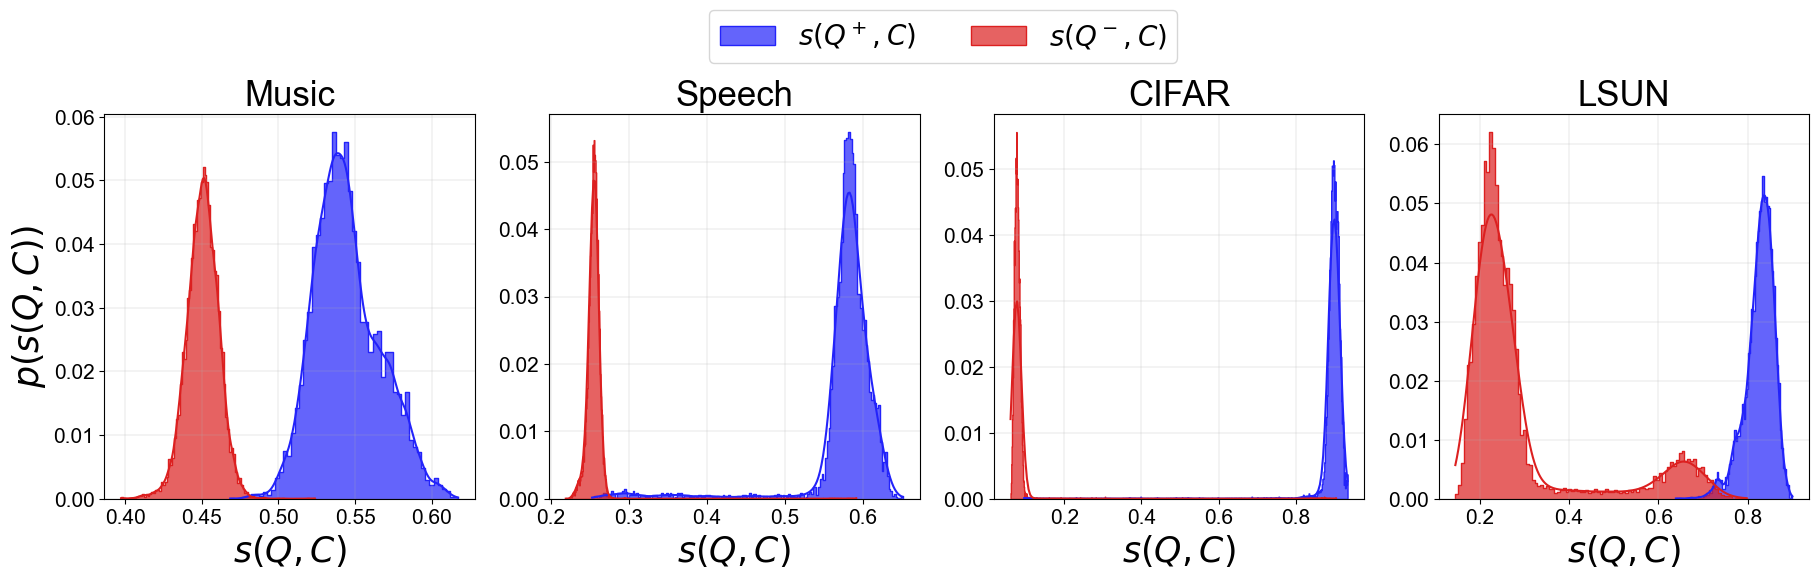

In [30]:
import pickle
with open("all_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

pos_all, neg_all = all_scores["pos"], all_scores["neg"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()

kwargs = {
    "kde": True, 
    "stat": "probability",
    "element": "step", 
    "common_norm": False,
    "alpha": 0.7
    # "bins": 50
}

myblue = "#2323fa"
myred = "#dc2020"

plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 25
title_fontsize = 25
label_fontsize = 15
legend_fontsize = 20

xfm = lambda x: x.capitalize() if x not in ["cifar", "lsun"] else x.upper()

np.random.seed(0)
for n, dataset in enumerate(["audio", "speech", "cifar", "lsun"]):
    ps, ns = pos_all[dataset][0], neg_all[dataset][0]
    dataset = "music" if dataset == "audio" else dataset
    # ps: 20_000, ns: 1_980_000
    sns.histplot(np.random.choice(ps, 10000, replace=False), ax=axes[n], color=myblue, label=r"$s(Q^+,C)$", **kwargs)
    sns.histplot(np.random.choice(ns, 10000, replace=False), ax=axes[n], color=myred, label=r"$s(Q^-,C)$", **kwargs)

    # axes[n].legend(loc='upper right', fontsize=15)
    if n == 0:
        axes[n].set_ylabel(r"$p(s(Q,C))$", fontsize=axis_fontsize)
    else:
        axes[n].set_ylabel("")
    axes[n].set_xlabel(r"$s(Q,C)$", fontsize=axis_fontsize)
    axes[n].set_title(f"{xfm(dataset)}", fontsize=title_fontsize)
    axes[n].tick_params(axis='both', which='major', labelsize=label_fontsize)
    axes[n].grid(linewidth=0.2)

    handles, labels = axes[n].get_legend_handles_labels()

legend = fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=legend_fontsize)
coords = legend.get_window_extent().get_points()[0]
fig.legends = []
scale = fig.get_window_extent().get_points()[1]
fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+legend_fontsize/80), loc=2, ncol=5, fontsize=legend_fontsize)
fig.savefig('score_distribution_sqc.pdf', bbox_inches='tight')
plt.show()

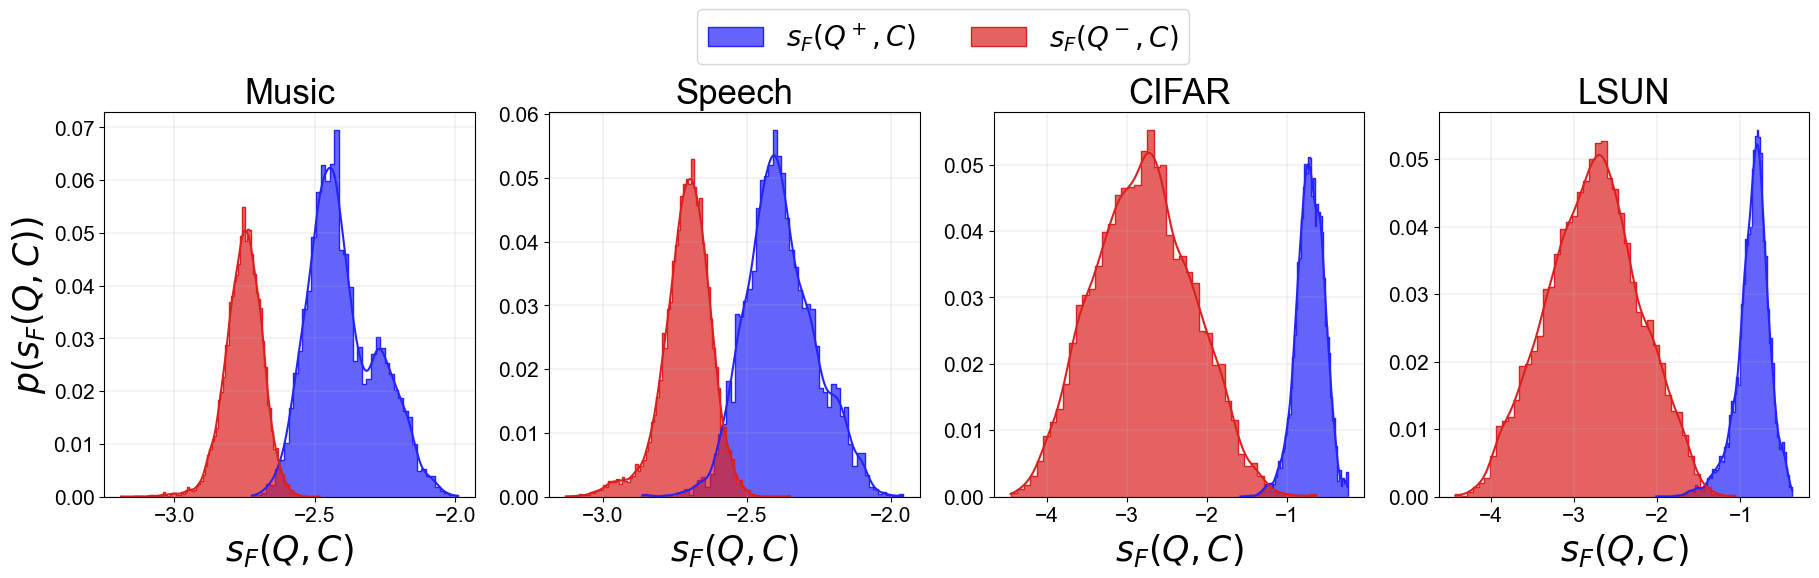

In [36]:
import pickle
with open("all_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

pos_all, neg_all = all_scores["pos"], all_scores["neg"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()

xfm = lambda x: x.capitalize() if x not in ["cifar", "lsun"] else x.upper()

np.random.seed(0)
for n, dataset in enumerate(["audio", "speech", "cifar", "lsun"]):
    ps, ns = pos_all[dataset][1], neg_all[dataset][1]
    dataset = "music" if dataset == "audio" else dataset
    # ps: 20_000, ns: 1_980_000
    sns.histplot(np.random.choice(-ps, 10_000, replace=False), ax=axes[n], color=myblue, label=r"$s_{F}(Q^+,C)$", **kwargs)
    sns.histplot(np.random.choice(-ns, 10_000, replace=False), ax=axes[n], color=myred, label=r"$s_{F}(Q^-,C)$", **kwargs)

    # axes[n].legend(loc='upper right', fontsize=15)
    if n == 0:
        # axes[n].set_ylabel(r"$p(s(Q,C))$", fontsize=axis_fontsize)
        axes[n].set_ylabel(r"$p(s_{F}(Q,C))$", fontsize=axis_fontsize)
    else:
        axes[n].set_ylabel("")
    # axes[n].set_xlabel(r"$s(Q,C)$", fontsize=axis_fontsize)
    axes[n].set_xlabel(r"$s_{F}(Q,C)$", fontsize=axis_fontsize)
    axes[n].set_title(f"{xfm(dataset)}", fontsize=title_fontsize)
    axes[n].tick_params(axis='both', which='major', labelsize=label_fontsize)
    axes[n].grid(linewidth=0.2)

    handles, labels = axes[n].get_legend_handles_labels()

legend = fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=legend_fontsize)
coords = legend.get_window_extent().get_points()[0]
fig.legends = []
scale = fig.get_window_extent().get_points()[1]
fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+legend_fontsize/80), loc=2, ncol=5, fontsize=legend_fontsize)
fig.savefig('score_distribution_normqc.pdf', bbox_inches='tight')
plt.show()

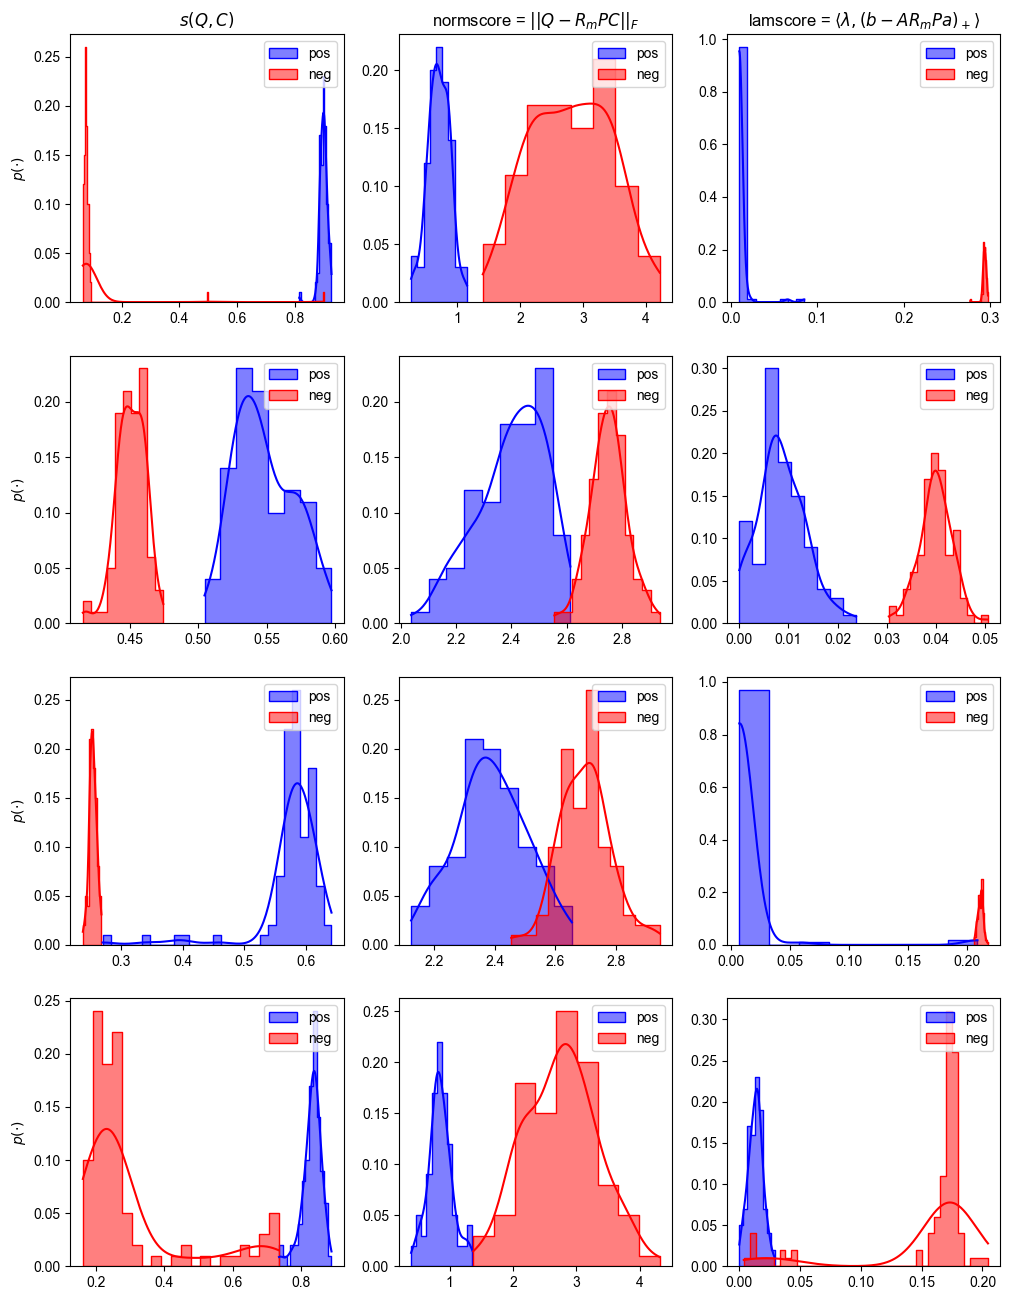

In [ ]:
import pickle
with open("plots_and_figures/all_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

pos_all, neg_all = all_scores["pos"], all_scores["neg"]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

kwargs = {
    "kde": True, 
    "stat": "probability",
    "element": "step", 
    "common_norm": False,
}

for n,dataset in enumerate(pos_all.keys()):
    ps, ns = pos_all[dataset], neg_all[dataset]
    for i, (pss, nss) in enumerate(zip(ps, ns)):
        sns.histplot(np.random.choice(pss, 100, replace=False), ax=axes[n][i], color='b', label="pos", **kwargs)
        sns.histplot(np.random.choice(nss, 100, replace=False), ax=axes[n][i], color='r', label="neg", **kwargs)
        if n==0:
            labels = [r'$s(Q,C)$', r'normscore = $||Q-R_mPC||_F$', r'lamscore = $\langle \lambda, (b - AR_mPa)_+ \rangle$']
            axes[n][i].set_title(f"{labels[i]}")
        axes[n][i].legend(loc='upper right')
        if i > 0:
            axes[n][i].set_ylabel("")
        else:
            axes[n][i].set_ylabel(r"$p(\cdot)$")
        # axes[n][i].text(0.5, 0.9, f"{dataset.upper()}", fontsize=14, ha='center', va='center', transform=axes[n][i].transAxes)
    # raise

In [ ]:
import pickle
with open("all_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

pos_all, neg_all = all_scores["pos"], all_scores["neg"]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

kwargs = {
    "kde": True, 
    "stat": "probability",
    "element": "step", 
    "common_norm": False,
}

for n,dataset in enumerate(pos_all.keys()):
    ps, ns = pos_all[dataset], neg_all[dataset]
    for i, (pss, nss) in enumerate(zip(ps, ns)):
        sns.histplot(np.random.choice(pss, 100, replace=False), ax=axes[n][i], color='b', label="pos", **kwargs)
        sns.histplot(np.random.choice(nss, 100, replace=False), ax=axes[n][i], color='r', label="neg", **kwargs)
        if n==0:
            labels = ["Net Score", "normscore", "lamscore"]
            axes[n][i].set_title(f"{labels[i]}")
        axes[n][i].legend(loc='upper right')
        if i > 0:
            axes[n][i].set_ylabel("")
        else:
            axes[n][i].set_ylabel(r"$p(\cdot)$")

        xlabels = [r"$s(Q,C)$", r"$||Q-R_mPC||_F$", r"$\langle \lambda, (b - AR_mPa)_+ \rangle$"]
        axes[n][i].set_xlabel(f"{xlabels[i]}")
        # axes[n][i].text(0.5, 0.9, f"{dataset.upper()}", fontsize=14, ha='center', va='center', transform=axes[n][i].transAxes)
    # raise